<a href="https://colab.research.google.com/github/pranavkrishnan9/spotify-popularity-eda/blob/main/P1_Linear_Regression_Model_onto_Spotify_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#required imports
import numpy as np
import pandas as pd
import sklearn as sk
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [4]:
#read dataset into spotify var for analysis
spotify = pd.read_csv("../content/spotify_dataset.csv")
spotify.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [6]:
# X/predictor must be a 2D DataFrame/array
X = spotify[['loudness']]
Y = spotify.popularity
#using scikit learn Linear Regression func
reg = LinearRegression().fit(X,Y)

In [ ]:
reg.coef_

array([0.22362587])

In [ ]:
reg.intercept_

np.float64(35.08545227772661)

In [ ]:
reg.score(X,Y)

0.0025424825695922193

<Axes: xlabel='loudness', ylabel='popularity'>

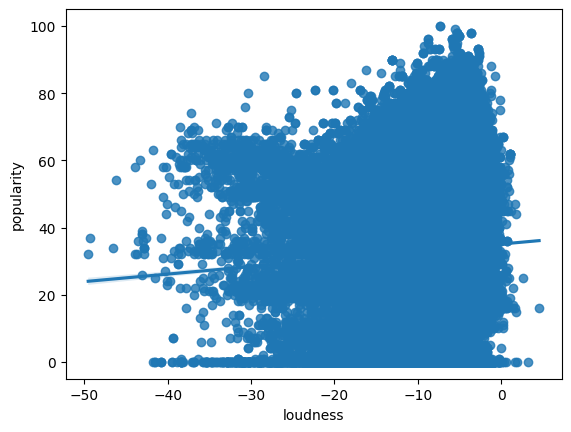

In [ ]:
#produces heavily clustered/scattered data -> backs up low R^2 score
sns.regplot(data = spotify, x = 'loudness', y = 'popularity')

In [9]:
# fill first col with 1s for B0
ones = np.ones((len(spotify), 1))
loudness = spotify[['loudness']].values
x1 = np.column_stack([ones, loudness])
x1_transpose = np.transpose(x1)
y1 = np.array(Y)

#Normal eq for finding B0 and B1 (intercept and coef) of lin regression formula: B = (x_transpose * x)^-1*x_transpose*y

x1_transpose = np.transpose(x1)
B = np.linalg.inv(x1_transpose @ x1) @ x1_transpose @ y1

B0 = B[0]
B1 = B[1]
B1

np.float64(0.2236258690705466)